<a href="https://colab.research.google.com/github/sig-gis/orbit_unops/blob/main/docs/studies/EE_built_area_detection_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install earthengine-api

import ee
import numpy as np
import pandas as pd
import requests
import ipywidgets as widgets
from functools import reduce
from IPython.display import display

In [3]:
from google.colab import userdata
cloud_project = userdata.get('cloud_project')

In [4]:
ee.Authenticate()

PROJECT = cloud_project

if PROJECT is None:
    ee.Initialize()
else:
    ee.Initialize(project=PROJECT)

In [5]:
# -------------------------------------------------------------------
# Config + datasets + AOI selector
# -------------------------------------------------------------------
MAP_YEAR = 2018
SAMPLE_POINTS_PER_CLASS = 1000
SAMPLE_SCALE = 10
EMBEDDING_SCALE = 10
TREES = 100
SEED = 42

embeddings   = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
ghs_built    = ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S_10m/2018").select("built_surface")
dynamic_world = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")          # 9-class LC + per-class probs; 'built' = class 6
GBA_FOLDER   = "projects/sat-io/open-datasets/GLOBAL_BUILDING_ATLAS"  # building footprints, ref year 2019, 5-deg tiles

GAUL       = {0: "FAO/GAUL/2015/level0", 1: "FAO/GAUL/2015/level1", 2: "FAO/GAUL/2015/level2"}
NAME_FIELD = {0: "ADM0_NAME", 1: "ADM1_NAME", 2: "ADM2_NAME"}

# AOI from GAUL. Pick country / level / region, then run the cells below.
countries = sorted(set(ee.FeatureCollection(GAUL[0]).aggregate_array("ADM0_NAME").getInfo()))
country_w = widgets.Dropdown(options=countries, value="Ireland", description="Country")
level_w   = widgets.Dropdown(options=[("level 0", 0), ("level 1", 1), ("level 2", 2)], value=1, description="Level")
region_w  = widgets.Dropdown(description="Region")

def _fill_regions(*_):
    if level_w.value == 0:
        region_w.options, region_w.disabled = [], True
        return
    region_w.disabled = False
    names = sorted(set(ee.FeatureCollection(GAUL[level_w.value])
                       .filter(ee.Filter.eq("ADM0_NAME", country_w.value))
                       .aggregate_array(NAME_FIELD[level_w.value]).getInfo()))
    region_w.options = names
    region_w.value = next((n for n in names if "cork" in n.lower()), names[0] if names else None)

country_w.observe(_fill_regions, "value")
level_w.observe(_fill_regions, "value")
_fill_regions()
display(widgets.HBox([country_w, level_w, region_w]))

In [33]:
# -------------------------------------------------------------------
# World Bank total population (SP.POP.TOTL) for the selected country
# -------------------------------------------------------------------
_norm = lambda s: "".join(c for c in s.lower() if c.isalnum())
_clist = requests.get("https://api.worldbank.org/v2/country",
                      params={"format": "json", "per_page": 400}, timeout=30).json()[1]
ISO3 = next((c["id"] for c in _clist if _norm(c["name"]) == _norm(country_w.value)),
            next((c["id"] for c in _clist if _norm(country_w.value) in _norm(c["name"])), None))

_pop = requests.get(f"https://api.worldbank.org/v2/country/{ISO3}/indicator/SP.POP.TOTL",
                    params={"format": "json", "date": f"2000:{MAP_YEAR}", "per_page": 100}, timeout=30).json()[1]
_pts = sorted((int(d["date"]), d["value"]) for d in (_pop or []) if d["value"] is not None)
pop_year, population = max([p for p in _pts if p[0] <= MAP_YEAR] or _pts)
print(f"{country_w.value} ({ISO3}) population, World Bank SP.POP.TOTL {pop_year}: {population:,.0f}")

Jamaica (JAM) population, World Bank SP.POP.TOTL 2018: 2,820,097


In [43]:
# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
def build_aoi():
    # GAUL 2015 lacks sub-national units for some countries (e.g. Ireland);
    # fall back to the country polygon when the chosen level has no region.
    if level_w.value == 0 or not region_w.value:
        fc = ee.FeatureCollection(GAUL[0]).filter(ee.Filter.eq("ADM0_NAME", country_w.value))
    else:
        fc = (ee.FeatureCollection(GAUL[level_w.value])
              .filter(ee.Filter.eq("ADM0_NAME", country_w.value))
              .filter(ee.Filter.eq(NAME_FIELD[level_w.value], region_w.value)))
    return fc.geometry(maxError=100)

def embeddings_by_year(year, aoi):
    s = ee.Date.fromYMD(year, 1, 1)
    return embeddings.filterDate(s, s.advance(1, "year")).filterBounds(aoi).mosaic().clip(aoi)

def gba_footprints(aoi):
    # GBA is a 5-degree tile grid (e.g. e030_n25_e035_n20). Find tiles covering the AOI and merge.
    import re
    box = aoi.bounds().coordinates().getInfo()[0]
    xs = [p[0] for p in box]; ys = [p[1] for p in box]
    aw, ae, asth, anth = min(xs), max(xs), min(ys), max(ys)

    resp = ee.data.listAssets(GBA_FOLDER)
    assets = resp.get("assets", [])
    tok = resp.get("nextPageToken")
    while tok:
        try:
            resp = ee.data.listAssets(GBA_FOLDER, pageToken=tok)
        except TypeError:
            break
        assets += resp.get("assets", [])
        tok = resp.get("nextPageToken")

    sgn = {"e": 1, "w": -1, "n": 1, "s": -1}
    pat = re.compile(r"([ew])(\d+)_([ns])(\d+)_([ew])(\d+)_([ns])(\d+)$")
    ids = []
    for a in assets:
        aid = a.get("id") or a.get("name", "")
        m = pat.search(aid.split("/")[-1])
        if not m:
            continue
        x1, y1 = sgn[m[1]] * int(m[2]), sgn[m[3]] * int(m[4])
        x2, y2 = sgn[m[5]] * int(m[6]), sgn[m[7]] * int(m[8])
        if max(x1, x2) >= aw and min(x1, x2) <= ae and max(y1, y2) >= asth and min(y1, y2) <= anth:
            ids.append(aid)

    fcs = [ee.FeatureCollection(i) for i in ids]
    merged = reduce(lambda x, y: x.merge(y), fcs) if fcs else ee.FeatureCollection([])
    return merged.filterBounds(aoi)

def built_raster(fc, aoi):
    return (fc.map(lambda f: f.set("b", 1))
              .reduceToImage(properties=["b"], reducer=ee.Reducer.first())
              .unmask(0).gt(0).rename("built").clip(aoi))

def accuracy_metrics(fc, truth_col, pred_col):
    def tag(f):
        y = ee.Number(f.get(truth_col)); p = ee.Number(f.get(pred_col))
        return f.set({"tp": p.multiply(y),
                      "fp": p.multiply(ee.Number(1).subtract(y)),
                      "tn": ee.Number(1).subtract(p).multiply(ee.Number(1).subtract(y)),
                      "fn": ee.Number(1).subtract(p).multiply(y)})
    s = fc.map(tag)
    d = ee.Dictionary({"n": s.size(), "tp": s.aggregate_sum("tp"), "fp": s.aggregate_sum("fp"),
                       "tn": s.aggregate_sum("tn"), "fn": s.aggregate_sum("fn")}).getInfo()
    tp, fp, tn, fn, n = d["tp"], d["fp"], d["tn"], d["fn"], d["n"]
    return {"n": n,
            "accuracy":  (tp + tn) / n  if n         else float("nan"),
            "precision": tp / (tp + fp) if (tp + fp) else float("nan"),
            "recall":    tp / (tp + fn) if (tp + fn) else float("nan")}

In [44]:
# -------------------------------------------------------------------
# GHS built-up labels -> sample embeddings -> train/validation split
# -------------------------------------------------------------------
aoi = build_aoi()

map_img = embeddings_by_year(MAP_YEAR, aoi)
bands = map_img.bandNames()

# stratifiedSample scans ~area/scale^2 pixels to find the sparse built class.
# 10 m over a big AOI = billions of pixels = timeout. Set the grid from the AOI
# so the scan stays ~2M cells; small AOIs fall back to 10 m.
_area = aoi.area(1e4).getInfo()
SAMPLE_SCALE = max(EMBEDDING_SCALE, int((_area / 2e6) ** 0.5))
print(f"AOI {_area/1e6:,.0f} km^2 -> SAMPLE_SCALE {SAMPLE_SCALE} m")

label_img = ghs_built.gt(0).unmask(0).rename("b1").toByte()

sample = (map_img.addBands(label_img).stratifiedSample(
    numPoints=SAMPLE_POINTS_PER_CLASS,
    classBand="b1",
    classValues=[0, 1],
    classPoints=[SAMPLE_POINTS_PER_CLASS, SAMPLE_POINTS_PER_CLASS],
    region=aoi,
    scale=SAMPLE_SCALE,
    geometries=True,
    seed=SEED,
    tileScale=16,
).filter(ee.Filter.notNull(bands)))

labeled = sample.randomColumn("random", seed=SEED)
training_set   = labeled.filter(ee.Filter.lt("random", 0.7))
validation_set = labeled.filter(ee.Filter.gte("random", 0.7))

AOI 1,189 km^2 -> SAMPLE_SCALE 24 m


In [45]:
print("AOI area km^2 :", aoi.area(1e4).divide(1e6).getInfo())
print("map_img bands :", map_img.bandNames().size().getInfo())
print("sample size   :", sample.size().getInfo())
print("labeled size  :", labeled.size().getInfo())
print("train / val   :", training_set.size().getInfo(), "/", validation_set.size().getInfo())

AOI area km^2 : 1188.8409754261131
map_img bands : 64
sample size   : 2000
labeled size  : 2000
train / val   : 1417 / 583


In [46]:
# -------------------------------------------------------------------
# Two approaches to built/not-built, compared on the held-out points we ALREADY have:
#   RF = smileRandomForest on embeddings (trained on GHS labels)
#   DW = Dynamic World, per-year median 'built' probability, thresholded
# References: GHS (b1, held-out) and GBA footprints (2019), read at those points.
# Reports per-method accuracy, map-to-map agreement, and co-located errors.
# -------------------------------------------------------------------
classifier = ee.Classifier.smileRandomForest(numberOfTrees=TREES, seed=SEED).train(
    features=training_set, classProperty="b1", inputProperties=bands)

# RF on the held-out points (already carry embeddings + b1)
held_out = validation_set.classify(classifier, "pred")

# DW alternative map and GBA reference map
_s = ee.Date.fromYMD(MAP_YEAR, 1, 1)
dw_built = (dynamic_world.filterDate(_s, _s.advance(1, "year")).filterBounds(aoi)
            .select("built").median().gte(0.5).rename("dw").toByte())
gba_built = built_raster(gba_footprints(aoi), aoi)          # band "built"

# Read DW + GBA at the SAME held-out points; no new sampling of the AOI
common = (dw_built.addBands(gba_built)
          .sampleRegions(collection=held_out, scale=EMBEDDING_SCALE, geometries=True, tileScale=16)
          .filter(ee.Filter.notNull(ee.List(["dw", "built"]))))

def _flags(f):
    t = ee.Number(f.get("built")); g = ee.Number(f.get("b1"))
    r = ee.Number(f.get("pred"));  d = ee.Number(f.get("dw"))
    one = ee.Number(1)
    return f.set({
        "n": 1, "agree": r.eq(d),
        "r11": r.eq(1).And(d.eq(1)), "r10": r.eq(1).And(d.eq(0)),
        "r01": r.eq(0).And(d.eq(1)), "r00": r.eq(0).And(d.eq(0)),
        "both_corr": r.eq(t).And(d.eq(t)), "both_wrong": r.neq(t).And(d.neq(t)),
        "rf_only_corr": r.eq(t).And(d.neq(t)), "dw_only_corr": d.eq(t).And(r.neq(t)),
        # RF / DW vs GBA (t)
        "rf_tp": r.multiply(t), "rf_fp": r.multiply(one.subtract(t)), "rf_fn": one.subtract(r).multiply(t),
        "dw_tp": d.multiply(t), "dw_fp": d.multiply(one.subtract(t)), "dw_fn": one.subtract(d).multiply(t),
        # DW vs GHS (g)
        "dwg_tp": d.multiply(g), "dwg_fp": d.multiply(one.subtract(g)), "dwg_fn": one.subtract(d).multiply(g),
    })

keys = ["n","agree","r11","r10","r01","r00","both_corr","both_wrong","rf_only_corr","dw_only_corr",
        "rf_tp","rf_fp","rf_fn","dw_tp","dw_fp","dw_fn","dwg_tp","dwg_fp","dwg_fn"]
S = common.map(_flags)
g = ee.Dictionary.fromLists(keys, [S.aggregate_sum(k) for k in keys]).getInfo()

n = g["n"]
def _prf(tp, fp, fn):
    tn = n - tp - fp - fn
    return {"n": n,
            "accuracy":  (tp + tn) / n  if n         else float("nan"),
            "precision": tp / (tp + fp) if (tp + fp) else float("nan"),
            "recall":    tp / (tp + fn) if (tp + fn) else float("nan")}

po = g["agree"] / n
a, b, c, d = g["r11"], g["r10"], g["r01"], g["r00"]
pe = ((a + b) / n) * ((a + c) / n) + ((c + d) / n) * ((b + d) / n)
kappa = (po - pe) / (1 - pe) if (1 - pe) else float("nan")

results = pd.DataFrame([
    {"method": "RF", "reference": "GHS held-out",       **accuracy_metrics(held_out, "b1", "pred")},
    {"method": "DW", "reference": "GHS held-out",       **_prf(g["dwg_tp"], g["dwg_fp"], g["dwg_fn"])},
    {"method": "RF", "reference": "GBA (held-out pts)",  **_prf(g["rf_tp"],  g["rf_fp"],  g["rf_fn"])},
    {"method": "DW", "reference": "GBA (held-out pts)",  **_prf(g["dw_tp"],  g["dw_fp"],  g["dw_fn"])},
])
print(results.round(4).to_string(index=False))
print()
print(f"RF vs DW agreement: {po:.4f}   Cohen's kappa: {kappa:.4f}   (n={n})")
print(f"  predicted built:  both={a}  RF-only={b}  DW-only={c}  neither={d}")
print(f"  co-error vs GBA:  both correct={g['both_corr']}  same mistake={g['both_wrong']}  "
      f"RF right/DW wrong={g['rf_only_corr']}  DW right/RF wrong={g['dw_only_corr']}")

method          reference   n  accuracy  precision  recall
    RF       GHS held-out 583    0.9005     0.9430  0.8522
    DW       GHS held-out 583    0.8130     0.9691  0.6460
    RF GBA (held-out pts) 583    0.7307     0.4411  0.9206
    DW GBA (held-out pts) 583    0.7873     0.5052  0.7778

RF vs DW agreement: 0.8748   Cohen's kappa: 0.7411   (n=583)
  predicted built:  both=192  RF-only=71  DW-only=2  neither=318
  co-error vs GBA:  both correct=406  same mistake=104  RF right/DW wrong=20  DW right/RF wrong=53


embedding years over AOI: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
 year   n  rf_built  dw_built  rf_dw_agree  rf_vs_ghs  dw_vs_ghs  rf_vs_gba  dw_vs_gba
 2017 582    0.4313    0.2955       0.8471     0.8694     0.7749     0.7440     0.7835
 2018 583    0.4563    0.3328       0.8559     0.8885     0.8130     0.7324     0.7873
 2019 583    0.4545    0.3173       0.8559     0.8834     0.7976     0.7376     0.7890
 2020 583    0.4700    0.3208       0.8302     0.8988     0.8045     0.7256     0.7925
 2021 583    0.4631    0.3276       0.8542     0.8851     0.8079     0.7358     0.7890
 2022 583    0.4614    0.3139       0.8388     0.8971     0.7907     0.7376     0.7822
 2023 583    0.4545    0.3190       0.8439     0.8902     0.7993     0.7410     0.7976
 2024 583    0.4563    0.3276       0.8645     0.8954     0.8079     0.7358     0.7959
 2025 583    0.4923    0.3122       0.8199     0.8937     0.7959     0.7101     0.8045


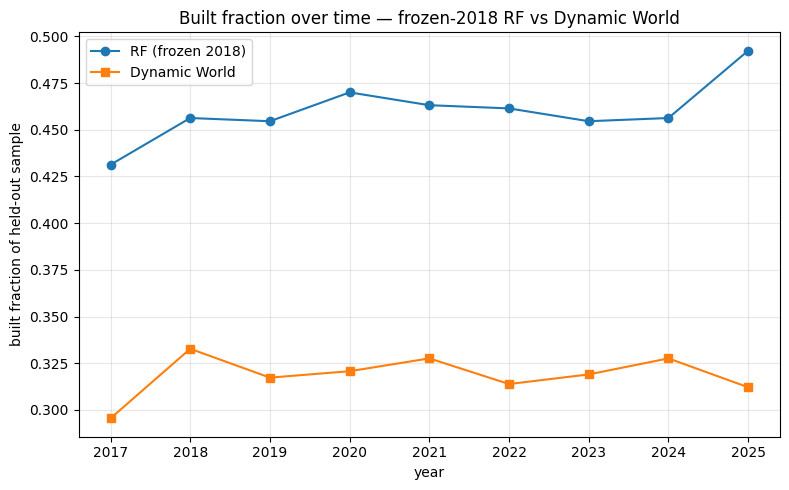

In [47]:
# -------------------------------------------------------------------
# Year-by-year generalization of the FROZEN 2018 RF.
# Apply the 2018 `classifier` to EACH year's embeddings at the SAME held-out
# points, and read per-year DW at those same points. GHS/GBA are single-epoch
# (they don't move year to year) so they're shown as per-year agreement only;
# the moving comparison is the built fraction: if RF jumps year to year while
# DW trends smoothly, DW is the steadier signal.
# Uses `classifier`, `validation_set`, `bands`, `aoi` from the cells above.
# -------------------------------------------------------------------
import matplotlib.pyplot as plt

# years that actually have embedding tiles over this AOI
_ts = embeddings.filterBounds(aoi).aggregate_array("system:time_start").getInfo()
years = sorted({pd.Timestamp(t, unit="ms").year for t in _ts})
print("embedding years over AOI:", years)

gba_built = built_raster(gba_footprints(aoi), aoi)   # static 2019 footprints reference

def _year_row(y):
    s = ee.Date.fromYMD(y, 1, 1)
    emb = embeddings.filterDate(s, s.advance(1, "year")).filterBounds(aoi).mosaic()
    dw  = (dynamic_world.filterDate(s, s.advance(1, "year")).filterBounds(aoi)
           .select("built").median().gte(0.5).rename("dw").toByte())
    fc = (emb.addBands(dw).addBands(gba_built)
          .sampleRegions(collection=validation_set, properties=["b1"],
                         scale=EMBEDDING_SCALE, geometries=False, tileScale=16)
          .filter(ee.Filter.notNull(bands.add("dw")))
          .classify(classifier, "rf"))

    def tag(f):
        r = ee.Number(f.get("rf")); d = ee.Number(f.get("dw"))
        g = ee.Number(f.get("b1")); b = ee.Number(f.get("built"))
        return f.set({"n": 1, "rf": r, "dw": d, "agree": r.eq(d),
                      "rfg": r.eq(g), "dwg": d.eq(g), "rfb": r.eq(b), "dwb": d.eq(b)})

    keys = ["n", "rf", "dw", "agree", "rfg", "dwg", "rfb", "dwb"]
    t = fc.map(tag)
    d = ee.Dictionary.fromLists(keys, [t.aggregate_sum(k) for k in keys]).getInfo()
    n = d["n"] or 1
    return {"year": y, "n": int(d["n"]),
            "rf_built": d["rf"] / n, "dw_built": d["dw"] / n,
            "rf_dw_agree": d["agree"] / n,
            "rf_vs_ghs": d["rfg"] / n, "dw_vs_ghs": d["dwg"] / n,
            "rf_vs_gba": d["rfb"] / n, "dw_vs_gba": d["dwb"] / n}

df = pd.DataFrame([_year_row(y) for y in years])
print(df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(df["year"], df["rf_built"], "o-", label="RF (frozen 2018)")
plt.plot(df["year"], df["dw_built"], "s-", label="Dynamic World")
plt.xlabel("year"); plt.ylabel("built fraction of held-out sample")
plt.title("Built fraction over time — frozen-2018 RF vs Dynamic World")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

In [48]:
# -------------------------------------------------------------------
# Does the 2018-trained RF generalize to an INDEPENDENT 2024 reference?
# Reference = ESRI/IO 10m Annual LULC, 2024, Built Area (class 7).
# Apply the FROZEN 2018 `classifier` to 2024 embeddings, and DW for 2024, at the
# SAME held-out points; score both against ESRI-2024 and against each other.
# Uses `classifier`, `validation_set`, `bands`, `aoi` from the cells above.
# -------------------------------------------------------------------
esri = ee.ImageCollection("projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS")
esri_built = (esri.filterDate("2024-01-01", "2025-01-01").filterBounds(aoi)
              .mosaic().select(0).eq(7).rename("esri").toByte())   # ESRI Built Area = class 7

_s = ee.Date.fromYMD(2024, 1, 1)
emb_2024 = embeddings.filterDate(_s, _s.advance(1, "year")).filterBounds(aoi).mosaic()
dw_2024  = (dynamic_world.filterDate(_s, _s.advance(1, "year")).filterBounds(aoi)
            .select("built").median().gte(0.5).rename("dw").toByte())

scored = (emb_2024.addBands(dw_2024).addBands(esri_built)
          .sampleRegions(collection=validation_set, properties=[],
                         scale=EMBEDDING_SCALE, geometries=False, tileScale=16)
          .filter(ee.Filter.notNull(bands.add("dw").add("esri")))
          .classify(classifier, "rf"))

def _flags(f):
    t = ee.Number(f.get("esri")); r = ee.Number(f.get("rf")); d = ee.Number(f.get("dw"))
    one = ee.Number(1)
    return f.set({
        "n": 1, "agree": r.eq(d),
        "r11": r.eq(1).And(d.eq(1)), "r10": r.eq(1).And(d.eq(0)),
        "r01": r.eq(0).And(d.eq(1)), "r00": r.eq(0).And(d.eq(0)),
        "both_corr": r.eq(t).And(d.eq(t)), "both_wrong": r.neq(t).And(d.neq(t)),
        "rf_only_corr": r.eq(t).And(d.neq(t)), "dw_only_corr": d.eq(t).And(r.neq(t)),
        "rf_tp": r.multiply(t), "rf_fp": r.multiply(one.subtract(t)), "rf_fn": one.subtract(r).multiply(t),
        "dw_tp": d.multiply(t), "dw_fp": d.multiply(one.subtract(t)), "dw_fn": one.subtract(d).multiply(t),
    })

keys = ["n","agree","r11","r10","r01","r00","both_corr","both_wrong","rf_only_corr","dw_only_corr",
        "rf_tp","rf_fp","rf_fn","dw_tp","dw_fp","dw_fn"]
S = scored.map(_flags)
g = ee.Dictionary.fromLists(keys, [S.aggregate_sum(k) for k in keys]).getInfo()

n = g["n"] or 1
def _prf(tp, fp, fn):
    tn = n - tp - fp - fn
    return {"n": n,
            "accuracy":  (tp + tn) / n  if n         else float("nan"),
            "precision": tp / (tp + fp) if (tp + fp) else float("nan"),
            "recall":    tp / (tp + fn) if (tp + fn) else float("nan")}

po = g["agree"] / n
a, b, c, d = g["r11"], g["r10"], g["r01"], g["r00"]
pe = ((a + b) / n) * ((a + c) / n) + ((c + d) / n) * ((b + d) / n)
kappa = (po - pe) / (1 - pe) if (1 - pe) else float("nan")

results = pd.DataFrame([
    {"method": "RF (frozen 2018)", "reference": "ESRI 2024", **_prf(g["rf_tp"], g["rf_fp"], g["rf_fn"])},
    {"method": "DW 2024",          "reference": "ESRI 2024", **_prf(g["dw_tp"], g["dw_fp"], g["dw_fn"])},
])
print(results.round(4).to_string(index=False))
print()
print(f"RF vs DW agreement (2024): {po:.4f}   Cohen's kappa: {kappa:.4f}   (n={n})")
print(f"  predicted built:  both={a}  RF-only={b}  DW-only={c}  neither={d}")
print(f"  vs ESRI 2024:  both correct={g['both_corr']}  same mistake={g['both_wrong']}  "
      f"RF right/DW wrong={g['rf_only_corr']}  DW right/RF wrong={g['dw_only_corr']}")

          method reference   n  accuracy  precision  recall
RF (frozen 2018) ESRI 2024 583    0.8971     0.9023  0.8759
         DW 2024 ESRI 2024 583    0.8542     0.9948  0.6934

RF vs DW agreement (2024): 0.8645   Cohen's kappa: 0.7206   (n=583)
  predicted built:  both=189  RF-only=77  DW-only=2  neither=315
  vs ESRI 2024:  both correct=471  same mistake=33  RF right/DW wrong=52  DW right/RF wrong=27


In [49]:
# -------------------------------------------------------------------
# Small contiguous test patch (~1 km^2) within the AOI.
# Build one multi-band raster over the patch: static refs (GHS, GBA, ESRI-2024)
# + per-year RF (frozen 2018 classifier on each year's embeddings) and DW.
# Export to the EXISTING Drive folder; filename carries country + a run tag so
# re-running doesn't overwrite/collide. Only the patch is computed.
# Uses `classifier`, `aoi`, `country_w`, `sample`, `embeddings`, `dynamic_world`.
# -------------------------------------------------------------------
import re as _re
from datetime import datetime

_slug = _re.sub(r"[^a-z0-9]+", "_", country_w.value.lower()).strip("_")
DRIVE_FOLDER = "alphaearth_inspect"                   # the folder we've been using; no new ones

# Center the patch where BOTH built and non-built `sample` points cluster (a built
# edge), reusing points already in memory -> the km^2 has contrast, not a solid
# built core. Override with CENTER = [lon, lat] for a specific spot.
_b  = sample.filter(ee.Filter.eq("b1", 1))
_nb = sample.filter(ee.Filter.eq("b1", 0))
_dfil = ee.Filter.withinDistance(distance=500, leftField=".geo", rightField=".geo", maxError=10)
_cand = ee.Join.saveAll("bn").apply(_b, _b, _dfil)        # built neighbors of each built point
_cand = ee.Join.saveAll("nn").apply(_cand, _nb, _dfil)    # non-built neighbors of each built point
_cand = _cand.map(lambda f: f.set(
    "mix", ee.List(f.get("bn")).size().multiply(ee.List(f.get("nn")).size())))
_best = ee.Feature(_cand.sort("mix", False).first())
if ee.Number(_best.get("mix")).getInfo() == 0:
    CENTER = aoi.centroid(1).coordinates().getInfo()
    print("no mixed built/non-built cluster; using AOI centroid:", CENTER)
else:
    CENTER = _best.geometry().coordinates().getInfo()
    print("patch center = built/non-built edge:", CENTER,
          " (built x nonbuilt within 500 m =", _best.get("mix").getInfo(), ")")
_h = 2000 / 111320.0                                   # ~500 m in degrees -> ~1 km box
patch = ee.Geometry.Rectangle([CENTER[0]-_h, CENTER[1]-_h, CENTER[0]+_h, CENTER[1]+_h])
print("patch area km^2:", round(patch.area(1).getInfo()/1e6, 3))

# static references over the patch (unmask so the export is clean 0/1, no nodata)
ghs_b  = ghs_built.gt(0).unmask(0).rename("ghs").toByte()
gba_b  = built_raster(gba_footprints(patch), patch).unmask(0).rename("gba").toByte()
esri_b = (ee.ImageCollection("projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS")
          .filterDate("2024-01-01", "2025-01-01").filterBounds(patch).mosaic()
          .select(0).eq(7).unmask(0).rename("esri2024").toByte())   # ESRI Built Area = class 7

# per-year RF + DW over the patch
_ts = embeddings.filterBounds(patch).aggregate_array("system:time_start").getInfo()
patch_years = sorted({pd.Timestamp(t, unit="ms").year for t in _ts})
print("embedding years over patch:", patch_years)

layers = ghs_b.addBands(gba_b).addBands(esri_b)
for y in patch_years:
    s = ee.Date.fromYMD(y, 1, 1)
    emb = embeddings.filterDate(s, s.advance(1, "year")).filterBounds(patch).mosaic()
    rf  = emb.classify(classifier).unmask(0).rename(f"rf_{y}").toByte()
    dw  = (dynamic_world.filterDate(s, s.advance(1, "year")).filterBounds(patch)
           .select("built").median().gte(0.5).unmask(0).rename(f"dw_{y}").toByte())
    layers = layers.addBands(rf).addBands(dw)

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")    # unique per run -> re-runs don't collide
fname = f"patch_{_slug}_{RUN_TAG}"
_proj = embeddings.filterBounds(patch).first().select(0).projection().getInfo()  # native UTM, 10 m
ee.batch.Export.image.toDrive(
    image=layers.clip(patch),
    description=fname,
    folder=DRIVE_FOLDER,
    fileNamePrefix=fname,
    region=patch,
    crs=_proj["crs"],
    crsTransform=_proj["transform"],
    maxPixels=1e9,
).start()
print(f"export started -> Drive/{DRIVE_FOLDER}/{fname}.tif")
print("band order: ghs, gba, esri2024, then rf_<yr>, dw_<yr> for", patch_years)

patch center = built/non-built edge: [-77.2059945545432, 17.799039376487375]  (built x nonbuilt within 500 m = 16 )
patch area km^2: 15.2
embedding years over patch: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
export started -> Drive/alphaearth_inspect/patch_jamaica_20260604_073356.tif
band order: ghs, gba, esri2024, then rf_<yr>, dw_<yr> for [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
reading: patch_jamaica_20260604_073356.tif
patch pixels: 156348

=== A) 2018 truth comparison (contiguous patch) ===
method reference      n  accuracy  precision  recall
    RF       GHS 156348    0.9703     0.7146  0.9386
    DW       GHS 156348    0.9793     0.8403  0.8586
    RF       GBA 156348    0.9326     0.2587  0.9554
    DW       GBA 156348    0.9513     0.3238  0.9300
RF vs DW agreement: 0.9756  kappa: 0.8337   (built both=10522 RF-only=3457 DW-only=352 neither=142017)
vs GBA: both correct=145369 same mistake=7170 RF right/DW wrong=448 DW right/RF wrong=3361

=== B) year-over-year (contiguous patch) ===
 year      n  rf_built  dw_built  rf_dw_agree  rf_vs_ghs  dw_vs_ghs  rf_vs_gba  dw_vs_gba
 2017 156348    0.0704    0.0659       0.9838     0.9780     0.9785     0.9499     0.9536
 2018 156348    0.0894    0.0695       0.9756     0.9703     0.9793  

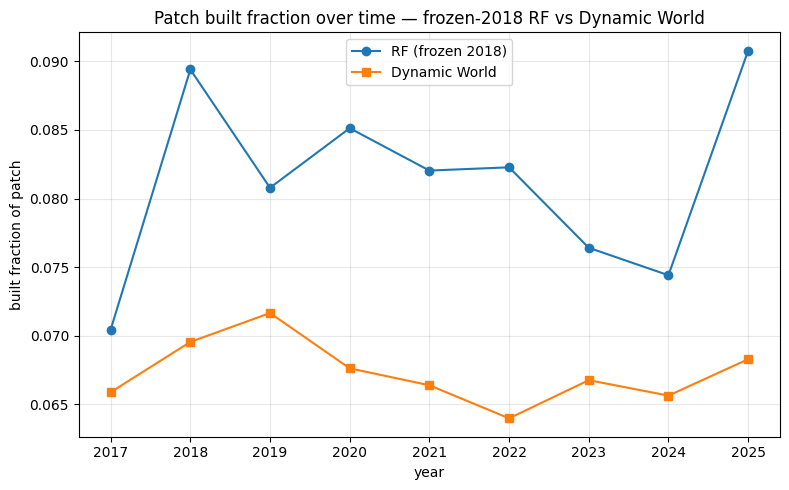


=== C) 2024 truth comparison vs ESRI (contiguous patch) ===
          method reference      n  accuracy  precision  recall
RF (frozen 2018) ESRI 2024 156348    0.9685     0.9301  0.7247
         DW 2024 ESRI 2024 156348    0.9701     1.0000  0.6873
RF vs DW agreement (2024): 0.9805  kappa: 0.8502   (built both=9422 RF-only=2212 DW-only=840 neither=143874)
vs ESRI 2024: both correct=150026 same mistake=3270 RF right/DW wrong=1399 DW right/RF wrong=1653


In [51]:
# -------------------------------------------------------------------
# Read the LATEST exported patch raster and re-run the three analyses over
# CONTIGUOUS pixels:
#   A) 2018 truth comparison  -> RF/DW vs GHS and vs GBA
#   B) year-over-year         -> built fraction of the patch, RF vs DW
#   C) 2024 truth comparison  -> RF/DW vs ESRI-2024
# Requires Cell 12 to have run AND its export task to have FINISHED.
# Uses DRIVE_FOLDER, _slug, patch_years, MAP_YEAR from Cell 12.
# -------------------------------------------------------------------
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import rasterio

drive.mount("/content/drive")
_files = sorted(glob.glob(f"/content/drive/MyDrive/{DRIVE_FOLDER}/patch_{_slug}_*.tif"))
assert _files, f"no patch_{_slug}_*.tif in Drive/{DRIVE_FOLDER} - did Cell 12's export finish?"
path = _files[-1]                                     # latest run (run tag sorts chronologically)
print("reading:", os.path.basename(path))
with rasterio.open(path) as ds:
    arr = ds.read().astype(float)

# reconstruct band order exactly as built in Cell 12 (don't rely on TIFF names)
names = ["ghs", "gba", "esri2024"] + [f"{m}_{y}" for y in patch_years for m in ("rf", "dw")]
band = {n: arr[i] for i, n in enumerate(names)}
print("patch pixels:", arr.shape[1] * arr.shape[2])

def _prf(pred, truth):
    n = pred.size
    tp = float(np.sum((pred == 1) & (truth == 1))); fp = float(np.sum((pred == 1) & (truth == 0)))
    tn = float(np.sum((pred == 0) & (truth == 0))); fn = float(np.sum((pred == 0) & (truth == 1)))
    return {"n": int(n),
            "accuracy":  (tp + tn) / n  if n         else float("nan"),
            "precision": tp / (tp + fp) if (tp + fp) else float("nan"),
            "recall":    tp / (tp + fn) if (tp + fn) else float("nan")}

def _pair(rf, dw, truth):
    n = rf.size
    a = int(np.sum((rf == 1) & (dw == 1))); b = int(np.sum((rf == 1) & (dw == 0)))
    c = int(np.sum((rf == 0) & (dw == 1))); d = int(np.sum((rf == 0) & (dw == 0)))
    po = (a + d) / n
    pe = ((a + b) / n) * ((a + c) / n) + ((c + d) / n) * ((b + d) / n)
    kappa = (po - pe) / (1 - pe) if (1 - pe) else float("nan")
    return {"agree": po, "kappa": kappa, "both": a, "rf_only": b, "dw_only": c, "neither": d,
            "both_correct": int(np.sum((rf == truth) & (dw == truth))),
            "same_mistake": int(np.sum((rf != truth) & (dw != truth))),
            "rf_right_dw_wrong": int(np.sum((rf == truth) & (dw != truth))),
            "dw_right_rf_wrong": int(np.sum((dw == truth) & (rf != truth)))}

ghs, gba, esri = band["ghs"], band["gba"], band["esri2024"]

# ---- A) 2018 truth comparison (RF/DW at MAP_YEAR vs GHS and GBA) ----
print("\n=== A) 2018 truth comparison (contiguous patch) ===")
if f"rf_{MAP_YEAR}" in band:
    rf0, dw0 = band[f"rf_{MAP_YEAR}"], band[f"dw_{MAP_YEAR}"]
    tA = pd.DataFrame([
        {"method": "RF", "reference": "GHS", **_prf(rf0, ghs)},
        {"method": "DW", "reference": "GHS", **_prf(dw0, ghs)},
        {"method": "RF", "reference": "GBA", **_prf(rf0, gba)},
        {"method": "DW", "reference": "GBA", **_prf(dw0, gba)},
    ])
    print(tA.round(4).to_string(index=False))
    pA = _pair(rf0, dw0, gba)
    print(f"RF vs DW agreement: {pA['agree']:.4f}  kappa: {pA['kappa']:.4f}   "
          f"(built both={pA['both']} RF-only={pA['rf_only']} DW-only={pA['dw_only']} neither={pA['neither']})")
    print(f"vs GBA: both correct={pA['both_correct']} same mistake={pA['same_mistake']} "
          f"RF right/DW wrong={pA['rf_right_dw_wrong']} DW right/RF wrong={pA['dw_right_rf_wrong']}")
else:
    print(f"no rf_{MAP_YEAR} band (no embeddings for {MAP_YEAR} over patch)")

# ---- B) year-over-year built fraction of the patch ----
print("\n=== B) year-over-year (contiguous patch) ===")
rows = []
for y in patch_years:
    rf_y, dw_y = band[f"rf_{y}"], band[f"dw_{y}"]
    rows.append({"year": y, "n": rf_y.size,
                 "rf_built": float(np.mean(rf_y)), "dw_built": float(np.mean(dw_y)),
                 "rf_dw_agree": float(np.mean(rf_y == dw_y)),
                 "rf_vs_ghs": float(np.mean(rf_y == ghs)), "dw_vs_ghs": float(np.mean(dw_y == ghs)),
                 "rf_vs_gba": float(np.mean(rf_y == gba)), "dw_vs_gba": float(np.mean(dw_y == gba))})
dfB = pd.DataFrame(rows)
print(dfB.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(dfB["year"], dfB["rf_built"], "o-", label="RF (frozen 2018)")
plt.plot(dfB["year"], dfB["dw_built"], "s-", label="Dynamic World")
plt.xlabel("year"); plt.ylabel("built fraction of patch")
plt.title("Patch built fraction over time \u2014 frozen-2018 RF vs Dynamic World")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

# ---- C) 2024 truth comparison (RF/DW at 2024 vs ESRI-2024) ----
print("\n=== C) 2024 truth comparison vs ESRI (contiguous patch) ===")
if "rf_2024" in band:
    rf4, dw4 = band["rf_2024"], band["dw_2024"]
    tC = pd.DataFrame([
        {"method": "RF (frozen 2018)", "reference": "ESRI 2024", **_prf(rf4, esri)},
        {"method": "DW 2024",          "reference": "ESRI 2024", **_prf(dw4, esri)},
    ])
    print(tC.round(4).to_string(index=False))
    pC = _pair(rf4, dw4, esri)
    print(f"RF vs DW agreement (2024): {pC['agree']:.4f}  kappa: {pC['kappa']:.4f}   "
          f"(built both={pC['both']} RF-only={pC['rf_only']} DW-only={pC['dw_only']} neither={pC['neither']})")
    print(f"vs ESRI 2024: both correct={pC['both_correct']} same mistake={pC['same_mistake']} "
          f"RF right/DW wrong={pC['rf_right_dw_wrong']} DW right/RF wrong={pC['dw_right_rf_wrong']}")
else:
    print("no rf_2024 band (no embeddings for 2024 over patch)")